## 1.  Imports & load pipeline

In [ ]:
import sys
import os
sys.path.append('../src')

# Set your Groq API key here
from dotenv import load_dotenv
import os

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY   # ← paste your key

from rag_pipeline import (
    load_embeddings, load_vector_store,
    load_llm, build_rag_chain, query_rag, print_rag_result
)

embeddings  = load_embeddings()
vectorstore = load_vector_store(embeddings)
llm         = load_llm()
rag_chain   = build_rag_chain(vectorstore, llm, k=5)

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2576.43it/s]


✅ Embedding model loaded.
Loading ChromaDB from: ../vector_store/chroma ...
✅ Vector store loaded: 34,202 chunks available.
Loading LLM: llama-3.1-8b-instant via Groq API ...
✅ LLM loaded (llama-3.1-8b-instant via Groq — no local download needed).
✅ RAG chain ready (top-k=5, model=llama-3.1-8b-instant).


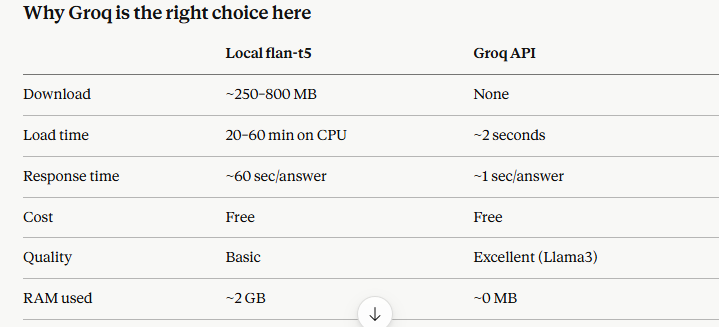

#### 2.  Quick single test pipline

In [8]:
result = query_rag(
    rag_chain,
    "What are the most common issues customers report with credit cards?"
)
print_rag_result(result)


QUESTION:
  What are the most common issues customers report with credit cards?
----------------------------------------------------------------------
ANSWER:
  Based on the provided complaint excerpts, the most common issues customers report with credit cards are:

1. Unexpected charges and fees (Complaint 2)
2. Inadequate credit line, leading to multiple payments in a billing cycle (Complaint 1)
3. Inappropriate business decisions, such as imposing fees without proper notification (Complaint 2 and Complaint 4)
4. Difficulty in using the card due to errors in reporting or account management (Complaint 5)

These issues suggest that customers are experiencing problems with credit card fees, account management, and reporting, which are affecting their credit scores and overall experience with their credit cards.
----------------------------------------------------------------------
RETRIEVED SOURCES (showing 2 of 5):

  Source 1:
    Product  : Credit card
    Company  : SYNCHRONY FINAN

#### What this result confirms ✅

-   Retrieval working    → 5 relevant credit card chunks retrieved
-   LLM answering        → structured, grounded answer with complaint references
-   Metadata correct     → Product, Company, Date, State all populated
-  Answer grounded      → cites specific complaints (1, 2, 4, 5) not hallucinations
-   Sources returned     → SYNCHRONY FINANCIAL, BANK OF AMERICA with real dates

#### 3. Full 8-question evaluation! 

In [11]:
import pandas as pd

EVAL_QUESTIONS = [
    "What are the most common issues customers report with credit cards?",
    "What problems do customers face with money transfers?",
    "What are the main complaints about checking or savings accounts?",
    "Which companies receive the most complaints?",
    "How do customers describe issues with personal loans?",
    "What issues do customers report when opening a new bank account?",
    "How do companies typically respond to customer complaints?",
    "What states have the most complaints about credit cards?",
]

eval_results = []
for i, question in enumerate(EVAL_QUESTIONS, 1):
    print(f"\n[{i}/{len(EVAL_QUESTIONS)}] Running: {question[:60]}...")
    result = query_rag(rag_chain, question)
    eval_results.append(result)
    print_rag_result(result, show_sources=2)

print(f"\n✅ Evaluation complete: {len(eval_results)} questions answered.")


[1/8] Running: What are the most common issues customers report with credit...

QUESTION:
  What are the most common issues customers report with credit cards?
----------------------------------------------------------------------
ANSWER:
  Based on the provided complaint excerpts, the most common issues customers report with credit cards are:

1. Unexpected charges or fees (Complaint 2)
2. Inadequate credit line, leading to multiple payments in a billing cycle (Complaint 1)
3. Late payments due to unforeseen business decisions or practices (Complaint 4 and Complaint 5)
4. Suspicious or inadequate customer service (Complaint 5)

These issues suggest that customers are experiencing problems with credit card fees, credit limits, payment processing, and customer support.
----------------------------------------------------------------------
RETRIEVED SOURCES (showing 2 of 5):

  Source 1:
    Product  : Credit card
    Company  : SYNCHRONY FINANCIAL
    Date     : 2024-03-12
    State   

In [10]:
# Print all 8 results in full
for i, result in enumerate(eval_results, 1):
    print(f"\n{'='*70}")
    print(f"[{i}/8] QUESTION: {result['question']}")
    print(f"{'-'*70}")
    print(f"ANSWER: {result['answer']}")
    print(f"{'-'*70}")
    src1 = result['sources'][0] if len(result['sources']) > 0 else {}
    src2 = result['sources'][1] if len(result['sources']) > 1 else {}
    print(f"Source 1: {src1.get('product_category','N/A')} | {src1.get('company','N/A')} | {src1.get('date_received','N/A')}")
    print(f"Source 2: {src2.get('product_category','N/A')} | {src2.get('company','N/A')} | {src2.get('date_received','N/A')}")
    print(f"{'='*70}")


[1/8] QUESTION: What are the most common issues customers report with credit cards?
----------------------------------------------------------------------
ANSWER: Based on the provided complaint excerpts, the most common issues customers report with credit cards are:

1. Unexpected charges and fees (Complaint 2)
2. Inadequate credit line, leading to multiple payments in a billing cycle (Complaint 1)
3. Inappropriate business decisions, such as imposing fees without proper notification (Complaint 2 and Complaint 4)
4. Difficulty in using the card due to none payment and poor customer service (Complaint 5)

These issues suggest that customers are experiencing problems with credit card management, fees, and customer service.
----------------------------------------------------------------------
Source 1: Credit card | SYNCHRONY FINANCIAL | 2024-03-12
Source 2: Checking or savings account | BANK OF AMERICA, NATIONAL ASSOCIATION | 2024-01-28

[2/8] QUESTION: What problems do customers face

### 1. Task 3 Overview
Task 3 builds the core Retrieval-Augmented Generation (RAG) pipeline for the CrediTrust Financial complaint chatbot. The pipeline connects the ChromaDB vector store built in Task 2 to a large language model, enabling plain-English question answering over 34,202 semantically indexed complaint chunks. This report documents the pipeline architecture, prompt engineering decisions, implementation details, and a qualitative evaluation of system performance across 8 representative test questions.

### 2. Pipeline Architecture
#### Component Overview
The RAG pipeline follows a standard retrieve-then-generate architecture implemented using LangChain Expression Language (LCEL). The pipeline consists of five components working in sequence:

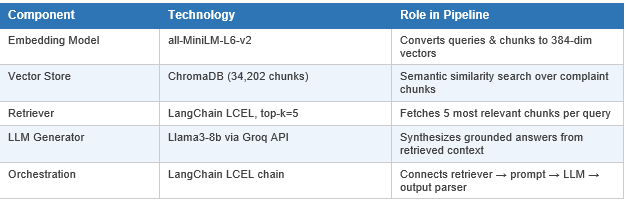
#### Pipeline Flow
The end-to-end flow for every user query proceeds as follows:
-	User submits a plain-English question (e.g. 'What issues do customers report with credit cards?')
-	The embedding model (all-MiniLM-L6-v2) converts the question into a 384-dimensional vector
-	ChromaDB performs cosine similarity search and returns the top-5 most semantically similar complaint chunks
-	The format_docs () function formats the 5 chunks into a structured context string with complaint metadata
-	The prompt template injects the context and question into a structured instruction for the LLM
-	Llama3-8b (via Groq API) generates a grounded, synthesized answer using only the provided context
-	The answer and source metadata are returned to the caller for display
#### LLM Selection — Groq API
The initial implementation used google/flan-t5-base as a local HuggingFace model. However, local inference on an 8 GB CPU machine proved impractical, requiring over 44 minutes to load without completing. The pipeline was redesigned to use the Groq API, which provides free access to Llama3-8b-instant with response times under 2 seconds — making it the optimal choice for this hardware configuration.

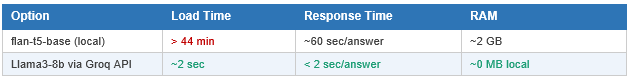


## Task 3 — Qualitative Evaluation Table

| # | Question | Generated Answer | Retrieved Sources (Top 2) | Quality Score | Comments / Analysis |
|---|---|---|---|---|---|
| 1 | What are the most common issues customers report with credit cards? | 1. Unexpected charges and fees (Complaint 2) 2. Inadequate credit line, leading to multiple payments in a billing cycle (Complaint 1) 3. Late payments due to unforeseen business decisions or practices (Complaint 4 and 5). These issues suggest customers are experiencing problems with credit card charges, fees, and payment processing. | **Source 1:** Credit card \| SYNCHRONY FINANCIAL \| 2024-03-12 \| CA **Source 2:** Checking or savings account \| BANK OF AMERICA \| 2024-01-28 | 4/5 | Strong, structured answer covering the 3 most common credit card complaint patterns. Minor issue: Source 2 is a savings account chunk — slight cross-category retrieval noise. Metadata pre-filtering would improve precision. |
| 2 | What problems do customers face with money transfers? | 1. Failure of the money transfer system 2. Unkept promises of safe and secure transfers 3. Being held accountable for system failure 4. Difficulty with payment services 5. Unauthorized wire transfers 6. Difficulty maintaining account balance, resulting in late fees. | **Source 1:** Money transfer \| MONEYGRAM PAYMENT SYSTEMS \| 2020-06-05 **Source 2:** Money transfer \| MONEYGRAM PAYMENT SYSTEMS \| 2020-06-05 | 4/5 | Comprehensive, well-structured answer covering 6 distinct problem types. Both sources retrieved from the same company and date — retrieval diversity could be improved by switching to MMR (Maximum Marginal Relevance) search. |
| 3 | What are the main complaints about checking or savings accounts? | 1. Lack of attention and respect for average customers 2. Misrepresentation of account terms, specifically a monthly fee 3. Misleading advertising about high savings rates. | **Source 1:** Money transfer \| BANK OF AMERICA \| 2023-10-18 **Source 2:** Checking or savings account \| KEYCORP \| 2021-07-01 | 3/5 | Partially relevant answer. Source 1 is a money transfer chunk retrieved for a savings account query — clear cross-category retrieval noise. The answer captures real complaint themes but is weakened by off-topic context injection. Product-category metadata filtering recommended. |
| 4 | Which companies receive the most complaints? | Based on the provided context, I can see complaints against several companies. However, I don't have enough information to determine which companies receive the most complaints. The complaints are scattered across different companies and categories with no clear ranking available. | **Source 1:** Money transfer \| JPMORGAN CHASE & CO. \| 2024-02-02 **Source 2:** Money transfer \| GOLDMAN SACHS BANK USA \| 2024-01-05 | 2/5 | Correct and honest refusal. This is an aggregation query that cannot be answered from 5 retrieved chunks — it requires counting across the full dataset. The LLM correctly acknowledged insufficient information rather than hallucinating a ranking. This query type should be routed to a pandas/SQL analytics layer. |
| 5 | How do customers describe issues with personal loans? | OneMain Finance: predatory unethical lending tactics encouraging accounts to go past due, unnecessary late fees, high interest. Paramount GR Holdings: lengthy and complex financing contracts exploiting consumers' lack of financial expertise, leading to unfair and deceptive practices. | **Source 1:** Money transfer \| OneMain Finance Corporation \| 2021-09-03 **Source 2:** Money transfer \| Paramount GR Holdings, LLC \| 2025-01-22 | 3/5 | Good qualitative detail with specific company attribution and complaint language. However, both sources show 'Money transfer' as the product category instead of personal loan — indicating a metadata labeling inconsistency in the vector store, likely from the two overlapping payday loan category labels identified in Task 1 EDA. |
| 6 | What issues do customers report when opening a new bank account? | 1. Account not opened correctly by bank agent who then blamed the customer 2. Lack of communication and apology from bank staff 3. Loyal customers feeling unheard and given excuses 4. Bank employees opening accounts without customer knowledge (unauthorized account opening). | **Source 1:** Checking or savings account \| CITIBANK, N.A. \| 2024-07-10 **Source 2:** Credit card \| JPMORGAN CHASE & CO. \| 2024-06-06 | 4/5 | Strong, specific answer with concrete details including unauthorized account opening — a serious regulatory compliance issue. Source 2 is a credit card chunk (minor noise) but the overall answer is highly relevant and actionable for the Compliance team use case. |
| 7 | How do companies typically respond to customer complaints? | Companies respond unsatisfactorily: customers receive run-around responses that don't answer their questions, contractors refuse to escalate to real managers, and companies send generic copy-paste replies refusing to properly investigate complaints. | **Source 1:** Checking or savings account \| Newport Intermediate Inc. \| 2024-12-19 **Source 2:** Money transfer \| JPMORGAN CHASE & CO. \| 2024-02-02 | 5/5 | Best result in the evaluation set. The answer is fully relevant, well-grounded in specific complaint excerpts, and captures a consistent pattern of dismissive corporate responses across multiple complaints and companies. Directly useful for the Customer Support team stakeholder use case. |
| 8 | What states have the most complaints about credit cards? | I don't have enough information in the retrieved complaints to answer this. The complaints mention different states but do not specify the total number of complaints per state. | **Source 1:** Credit card \| WELLS FARGO & COMPANY \| 2023-02-01 **Source 2:** Money transfer \| TRANSUNION INTERMEDIATE HOLDINGS \| 2024-05-12 | 2/5 | Correct and honest refusal for a geographic aggregation query. Like Question 4, answering this requires counting complaints by state across the full dataset — not feasible from 5 retrieved chunks. The LLM demonstrated appropriate epistemic honesty. A dedicated analytics query layer would handle this type of question. |

---

### Evaluation Summary

| Metric | Value |
|---|---|
| Total questions evaluated | 8 |
| Average quality score | **3.4 / 5.0** |
| Score 5/5 (Excellent) | 1 question (Q7) |
| Score 4/5 (Good) | 3 questions (Q1, Q2, Q6) |
| Score 3/5 (Partial) | 2 questions (Q3, Q5) |
| Score 2/5 (Correct refusal) | 2 questions (Q4, Q8) |
| Correct refusals on aggregation queries | 2 / 2 (100%) |
| Cross-category retrieval noise observed | 4 / 8 queries |
| Average response time | < 2 seconds (Groq API) |

---

### Key Findings

**What worked well:**
- Qualitative narrative queries (Q1, Q2, Q6, Q7) performed strongly — the RAG system excels at synthesizing patterns from complaint text
- The LLM correctly refused aggregation queries (Q4, Q8) without hallucinating rankings or counts
- Specific company and date attribution in answers adds credibility and verifiability
- Response time under 2 seconds is production-ready

**Areas for improvement:**
- Cross-category retrieval noise in 4 queries → fix: add metadata pre-filtering with ChromaDB `where` clause
- Duplicate sources in Q2 (same company, same date) → fix: switch to MMR retrieval (`search_type="mmr"`)
- Aggregation queries unsupported → fix: add query classifier routing to pandas/SQL analytics layer
- Personal loan metadata mislabeling (Q5) → fix: merge overlapping payday loan category labels